# Adaptive Variational Nonlinear Chirp Mode Decomposition (AVNCMD)

This notebook introduces the main ideas behind **Adaptive Variational Nonlinear Chirp Mode Decomposition (AVNCMD)** and provides executable examples with PySDKit.

We pay special attention to **how adaptivity works**: AVNCMD removes the need for a hand-tuned bandwidth parameter $\alpha$ in VNCMD by combining (i) a Bayesian sparse estimation of demodulated amplitudes and (ii) a data-driven instantaneous-frequency (IF) update that rebuilds the dictionary each iteration.

**Reference**

> H. Liang, X. Ding, A. Jakobsson, X. Tu, Y. Huang.  
> *Adaptive Variational Nonlinear Chirp Mode Decomposition.*  
> IEEE ICASSP 2022.  
> [DOI: 10.1109/ICASSP43922.2022.9746147](https://doi.org/10.1109/ICASSP43922.2022.9746147)

The implementation follows the authors' open MATLAB code: [HauLiang/AVNCMD](https://github.com/HauLiang/AVNCMD).

## 1. Why AVNCMD?

**Nonlinear chirp signals (NCSs)** have time-varying instantaneous amplitudes (IAs) and instantaneous frequencies (IFs). Classical Fourier tools only give global frequency content; STFT / SST improve time–frequency localization but can still struggle with strongly modulated wide-band modes.

**Variational Nonlinear Chirp Mode Decomposition (VNCMD)** (Chen et al., 2017) is a powerful variational method: it demodulates each chirp into a pair of narrow-band signals $(u_k, v_k)$ and jointly estimates modes and IFs.  
Its main practical limitation is the **bandwidth parameter $\alpha$**: performance depends heavily on this user-chosen constant, and a single fixed $\alpha$ rarely fits all NCSs.

**AVNCMD** keeps the VNCMD demodulation geometry but replaces the fixed-$\alpha$ ridge regression by a **Bayesian / RVM-style sparse solve**, then **adaptively updates IFs and rebuilds the dictionary** from the data. Empirically this yields more accurate IAs/IFs without carefully tuning $\alpha$.

## 2. From VNCMD to AVNCMD: core formulas

### 2.1 Nonlinear chirp model and demodulation

A multi-component NCS is written as

$$
g(t)=\sum_{k=1}^{K} a_k(t)\,\cos\!\left(2\pi\int_0^t f_k(s)\,ds+\varphi_k\right).
$$

Using a demodulation frequency $\tilde f_k(t)$ (an estimate of $f_k$), the same signal can be rewritten as

$$
g(t)=\sum_{k=1}^{K}\Big[
u_k(t)\,\cos\theta_k(t)+v_k(t)\,\sin\theta_k(t)
\Big],
\qquad
\theta_k(t)=2\pi\int_0^t \tilde f_k(s)\,ds,
$$

where the demodulated amplitudes $u_k,v_k$ become **narrow-band** when $\tilde f_k \approx f_k$. Then

$$
a_k(t)=\sqrt{u_k(t)^2+v_k(t)^2}.
$$

### 2.2 VNCMD variational problem (and the $\alpha$ issue)

VNCMD minimizes reconstruction error while penalizing the bandwidth of $(u_k,v_k)$ via second derivatives:

$$
\min_{u_k,v_k,\tilde f_k}
\alpha\,\Big\|g-\sum_k g_k\Big\|_2^2
+\sum_k\big(\|u_k''\|_2^2+\|v_k''\|_2^2\big).
$$

After sampling, this becomes a linear model $g \approx A x$ with a second-difference smoother $D$:

$$
\min_x\;\alpha\|g-Ax\|_2^2+\|Dx\|_2^2,
$$

where the dictionary $A$ is built from $\cos\theta_k$ and $\sin\theta_k$ (diagonal blocks).  
**Problem:** $\alpha$ must be chosen a priori and controls the trade-off between fidelity and smoothness.

### 2.3 Estimating the NCS without a fixed $\alpha$ (Section 3.1)

AVNCMD rewrites the constrained / differenced problem so that the smooth part $w$ of the coefficients is estimated by

$$
\min_w\;\alpha\|y-\Phi w\|_2^2+\|w\|_2^2,
$$

but **does not fix $\alpha$ by hand**. Instead it treats this as a sparse Bayesian regression (next subsection) and recovers $x$ from the estimated $w$ (and the complementary $\theta$ block).

In PySDKit this step is `estimate_ncs(A, D, signal, K, N)`.

### 2.4 Bayesian strategy: the first adaptive mechanism (Section 3.2)

Assume Gaussian noise and an independent Gaussian prior on each coefficient of $w$:

$$
p(y\mid w,\gamma_0)=\mathcal N(y\mid \Phi w,\gamma_0^{-1}I),
\qquad
p(w\mid\gamma)=\prod_j \mathcal N(w_j\mid 0,\gamma_j^{-1}).
$$

The posterior $p(w\mid y,\gamma_0,\gamma)$ is Gaussian with mean/covariance

$$
\mu=\gamma_0^{-1}\Sigma\Phi^\top y,
\qquad
\Sigma=(\gamma_0^{-1}\Phi^\top\Phi+\Lambda)^{-1},
\quad\Lambda=\mathrm{diag}(\gamma).
$$

Hyperparameters $(\gamma_0,\gamma)$ are learned by maximizing the marginal likelihood (type-II ML / RVM-style updates):

$$
\gamma_j^{\mathrm{new}}=\frac{1-\gamma_j^{\mathrm{old}}\Sigma_{jj}}{\mu_j^2},
\qquad
\gamma_0^{\mathrm{new}}=\frac{m-\sum_j\gamma_j^{\mathrm{new}}}{\|y-\Phi\mu\|_2^2}.
$$

**Why this is adaptive:**

- Coefficients that do not explain the data get large $\gamma_j$ and are pruned (sparse active set).
- The effective regularization strength is **learned from the residual**, so there is no need to pick VNCMD's $\alpha$ for each signal.
- The active dictionary for $w$ is therefore **data-driven**.

In PySDKit this is `bayesian_strategy(Phi, y)`.

### 2.5 Data-driven IF update: the second adaptive mechanism (Section 3.3)

After estimating $x^{(i)}$ (hence $u_k^{(i)},v_k^{(i)}$), AVNCMD extracts the **IF increment** by arctangent demodulation:

$$
\Delta f_k^{(i)}(t)
=-
\frac{1}{2\pi}\,
\frac{\mathrm d}{\mathrm d t}\arctan\!\left(\frac{v_k^{(i)}}{u_k^{(i)}}\right)
=
\frac{v_k u_k'-u_k v_k'}{2\pi\,(u_k^2+v_k^2)}.
$$

(Implementation note: the MATLAB / PySDKit code uses the equivalent finite-difference form with swapped derivative roles; the geometric meaning is the same.)

Because discrete derivatives are noisy, the increment is **low-pass corrected**:

$$
\Delta\tilde f_k^{(i)}=(I+\beta H^\top H)^{-1}\Delta f_k^{(i)},
$$

and the IF estimate is updated

$$
\tilde f_k^{(i+1)}=\tilde f_k^{(i)}+\Delta\tilde f_k^{(i)}
\quad(\text{implemented as }|\tilde f-\Delta\tilde f|\text{ for positivity}).
$$

Finally the dictionary $A$ is **rebuilt** from the new phases $\theta_k(t)=2\pi\int \tilde f_k$, so the next Bayesian solve sees a better demodulation basis.

### Gradual $\beta$ schedule (implementation detail)

In the reference MATLAB code (and PySDKit), the filter parameter is **annealed** during outer iterations:

$$
\beta_{\mathrm{thin}}=10^{(\mathrm{iter})/36-10},
\qquad
\beta_{\mathrm{thin}}\leftarrow\min(\beta_{\mathrm{thin}},\beta_{\mathrm{user}}).
$$

Early iterations use a larger effective bandwidth (more aggressive IF correction); later iterations tighten toward the user `beta` (default $10^{-6}$). This is a third, practical adaptivity layer that stabilizes IF tracking.

## 3. Algorithm sketch

```text
Input:  g(t), sampling rate fs, initial IF guesses tilde{f}_k(t) (often constant seeds)
Output: estIF, estMode, estIA

1. Build dictionary A from current tilde{f}_k (cos/sin of integrated phase).
2. Repeat until modes stabilize or max_iter:
   a. Anneal beta_thin = min(10^(iter/36 - 10), beta).
   b. Estimate demodulated coefficients x via Bayesian NCS solve (estimate_ncs).
      → adaptive sparsity / effective alpha from data.
   c. For each mode k:
        - extract (u_k, v_k) from x
        - compute Δf_k by arctangent demodulation
        - smooth Δf_k with (I + (2/beta_thin) HᵀH)⁻¹  [PySDKit / MATLAB form]
        - update tilde{f}_k and rebuild blocks of A
        - form mode g_k = A_k x_k
   d. Check relative change of modes; stop if < tol.
3. Return final IFs, modes, and IAs a_k = sqrt(u_k² + v_k²).
```

**Adaptivity in one sentence:** each outer iteration *learns* a sparse demodulated representation for the current dictionary, then *corrects* the IFs from that representation and *rebuilds* the dictionary—so bandwidth and carrier frequencies co-adapt to the signal.

In [1]:
import sys
from pathlib import Path

# Prefer the local source tree when running from the repo
ROOT = Path.cwd().resolve()
if (ROOT / "pysdkit").is_dir() and str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "pysdkit").is_dir() and str(ROOT.parent) not in sys.path:
    sys.path.insert(0, str(ROOT.parent))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import AVNCMD
from pysdkit.plot import plot_IMFs, plot_signal

print(AVNCMD())

Adaptive Variational Nonlinear Chirp Mode Decomposition (AVNCMD)


## 4. Build a demo signal

We use a shortened version of the official MATLAB `Demo_AVNCMD.m`: two nonlinear chirps with decaying amplitudes.  
Sampling rate is reduced (`fs=200`) so the notebook runs quickly; the structure matches the paper example.

signal length N=200, fs=200.0 Hz


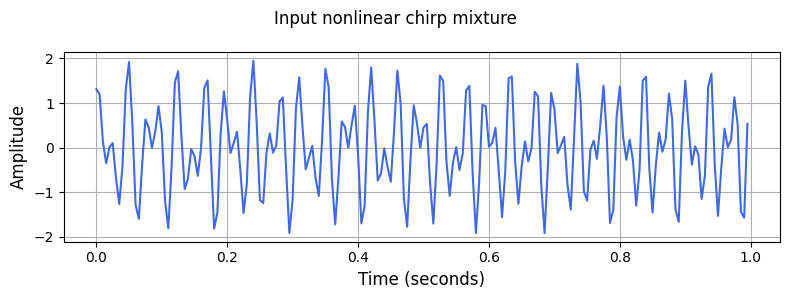

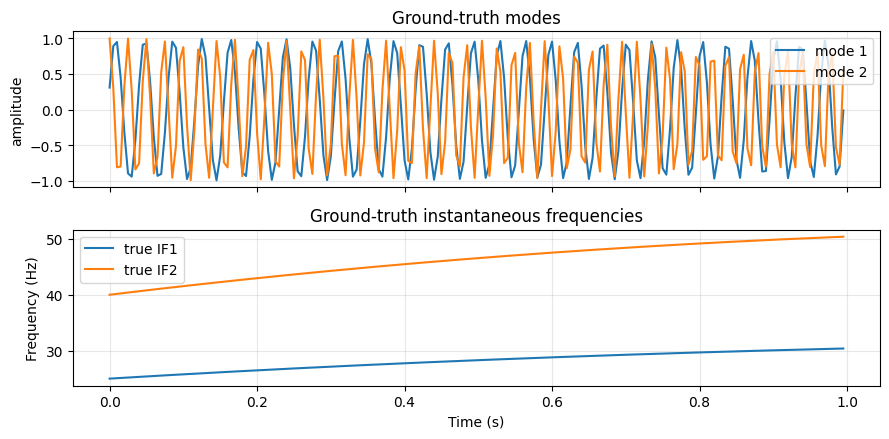

In [2]:
def make_demo_signal(fs: float = 200.0, T: float = 1.0):
    """Two-component nonlinear chirp (Demo_AVNCMD.m style)."""
    t = np.arange(0.0, T, 1.0 / fs)

    a1 = np.exp(-0.03 * t)
    a2 = np.exp(-0.06 * t)

    # True instantaneous frequencies
    f_1t = 25 + 8 * t - 3 * t**2 + 0.4 * t**3
    f_2t = 40 + 16 * t - 6 * t**2 + 0.4 * t**3

    g_1t = a1 * np.cos(2 * np.pi * (0.8 + 25 * t + 4 * t**2 - 1 * t**3 + 0.1 * t**4))
    g_2t = a2 * np.cos(2 * np.pi * (1 + 40 * t + 8 * t**2 - 2 * t**3 + 0.1 * t**4))
    signal = g_1t + g_2t
    return t, signal, g_1t, g_2t, f_1t, f_2t, a1, a2


fs = 200.0
t, signal, g_1t, g_2t, f_1t, f_2t, a1, a2 = make_demo_signal(fs=fs, T=1.0)
print(f"signal length N={signal.size}, fs={fs} Hz")

fig = plot_signal(t, signal)
fig.suptitle("Input nonlinear chirp mixture", fontsize=12)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
axes[0].plot(t, g_1t, label="mode 1")
axes[0].plot(t, g_2t, label="mode 2")
axes[0].set_ylabel("amplitude")
axes[0].set_title("Ground-truth modes")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, f_1t, label="true IF1")
axes[1].plot(t, f_2t, label="true IF2")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")
axes[1].set_title("Ground-truth instantaneous frequencies")
axes[1].legend(loc="upper left")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Run AVNCMD

Initial IFs are **constant seeds** near the true trajectories (28 Hz and 48 Hz), as in the MATLAB demo.  
AVNCMD then adapts these curves iteration by iteration.

Key parameters:

| Parameter | Role |
|-----------|------|
| `iniIF` | Initial IF matrix, shape `(K, N)` |
| `beta` | Cap on the IF low-pass filter parameter |
| `tol` | Relative mode-change stopping threshold |
| `max_iter` | Maximum outer iterations |

In [3]:
iniIF = np.vstack([28.0 * np.ones_like(t), 48.0 * np.ones_like(t)])

avncmd = AVNCMD(beta=1e-6, tol=1e-5, max_iter=30)
estIF, estMode, estIA = avncmd.fit_transform(signal, iniIF=iniIF, fs=fs)

print(f"estIF:   {estIF.shape}")
print(f"estMode: {estMode.shape}")
print(f"estIA:   {estIA.shape}")
print(f"outer iterations stored: {avncmd.estIF.shape[-1]} (incl. init)")


def relative_error(est, ref):
    return np.linalg.norm(est - ref) / np.linalg.norm(ref)


# Mode / IF labels may swap; pick the better matching assignment
re_if_direct = relative_error(estIF[0], f_1t) + relative_error(estIF[1], f_2t)
re_if_swap = relative_error(estIF[0], f_2t) + relative_error(estIF[1], f_1t)
swap = re_if_swap < re_if_direct
if swap:
    estIF = estIF[[1, 0]]
    estMode = estMode[[1, 0]]
    estIA = estIA[[1, 0]]
    print("Note: mode order swapped to match ground truth.")

print(f"IF1 relative error:   {relative_error(estIF[0], f_1t):.4e}")
print(f"IF2 relative error:   {relative_error(estIF[1], f_2t):.4e}")
print(f"Mode1 relative error: {relative_error(estMode[0], g_1t):.4e}")
print(f"Mode2 relative error: {relative_error(estMode[1], g_2t):.4e}")
print(f"IA1 relative error:   {relative_error(estIA[0], a1):.4e}")
print(f"IA2 relative error:   {relative_error(estIA[1], a2):.4e}")

estIF:   (2, 200)
estMode: (2, 200)
estIA:   (2, 200)
outer iterations stored: 31 (incl. init)
IF1 relative error:   6.2800e-03
IF2 relative error:   8.6055e-03
Mode1 relative error: 9.2471e-03
Mode2 relative error: 3.2242e-02
IA1 relative error:   5.0284e-03
IA2 relative error:   4.5033e-03


## 6. Visualize the decomposition

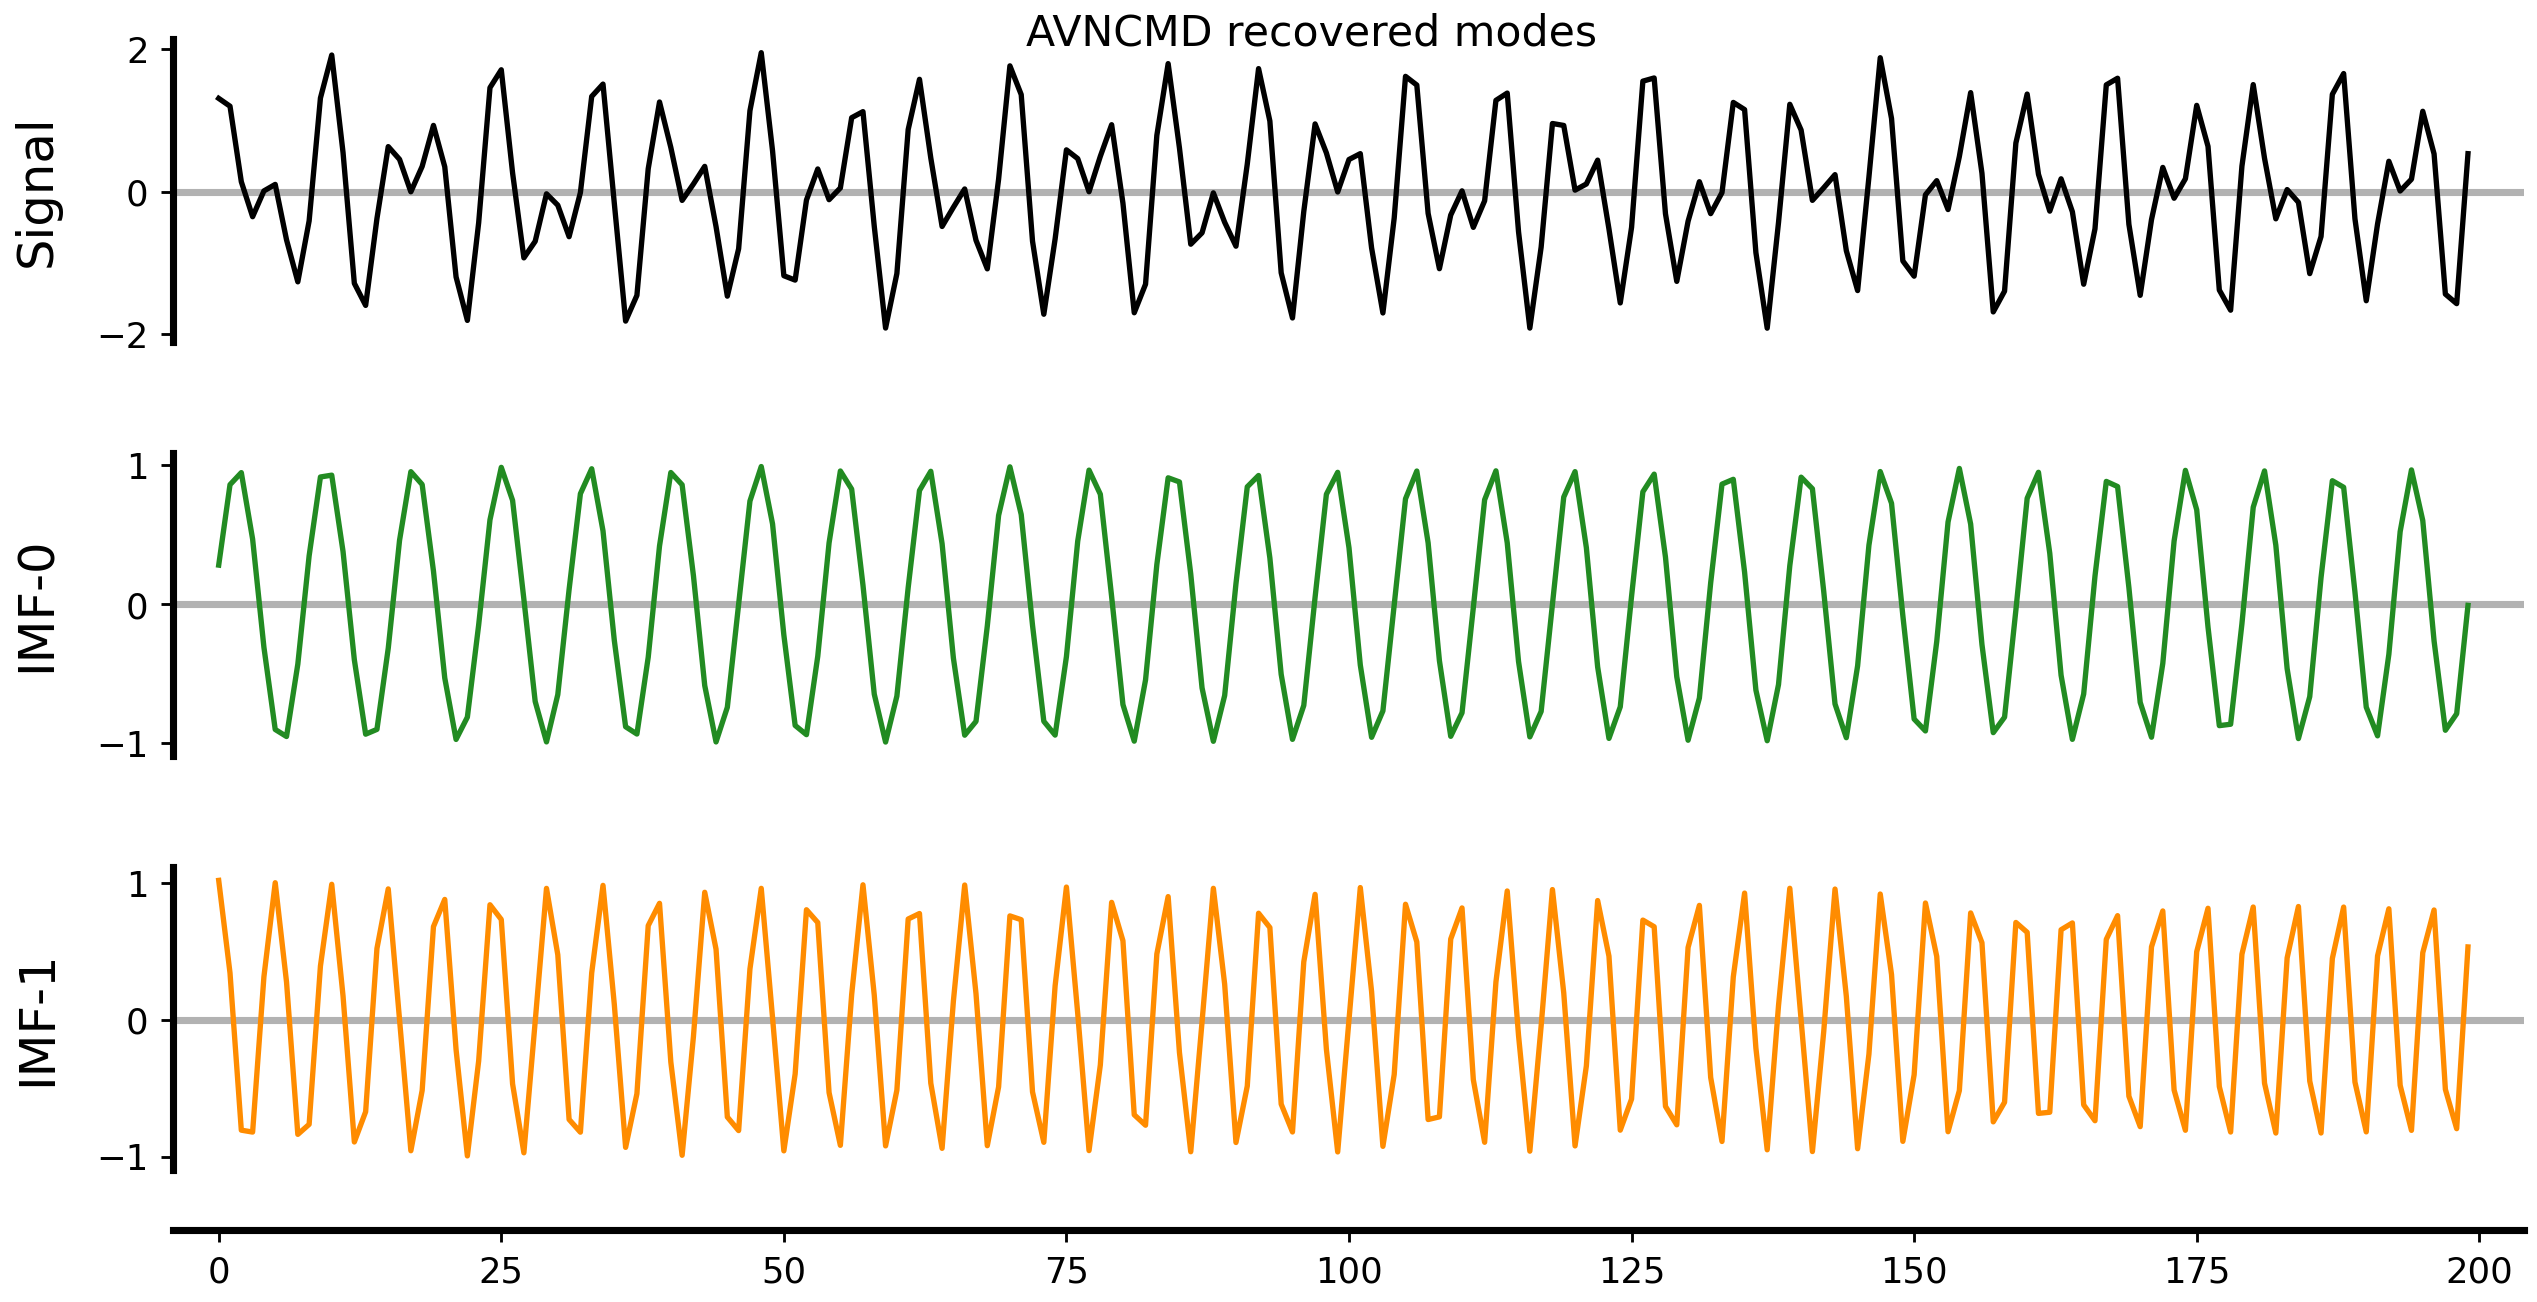

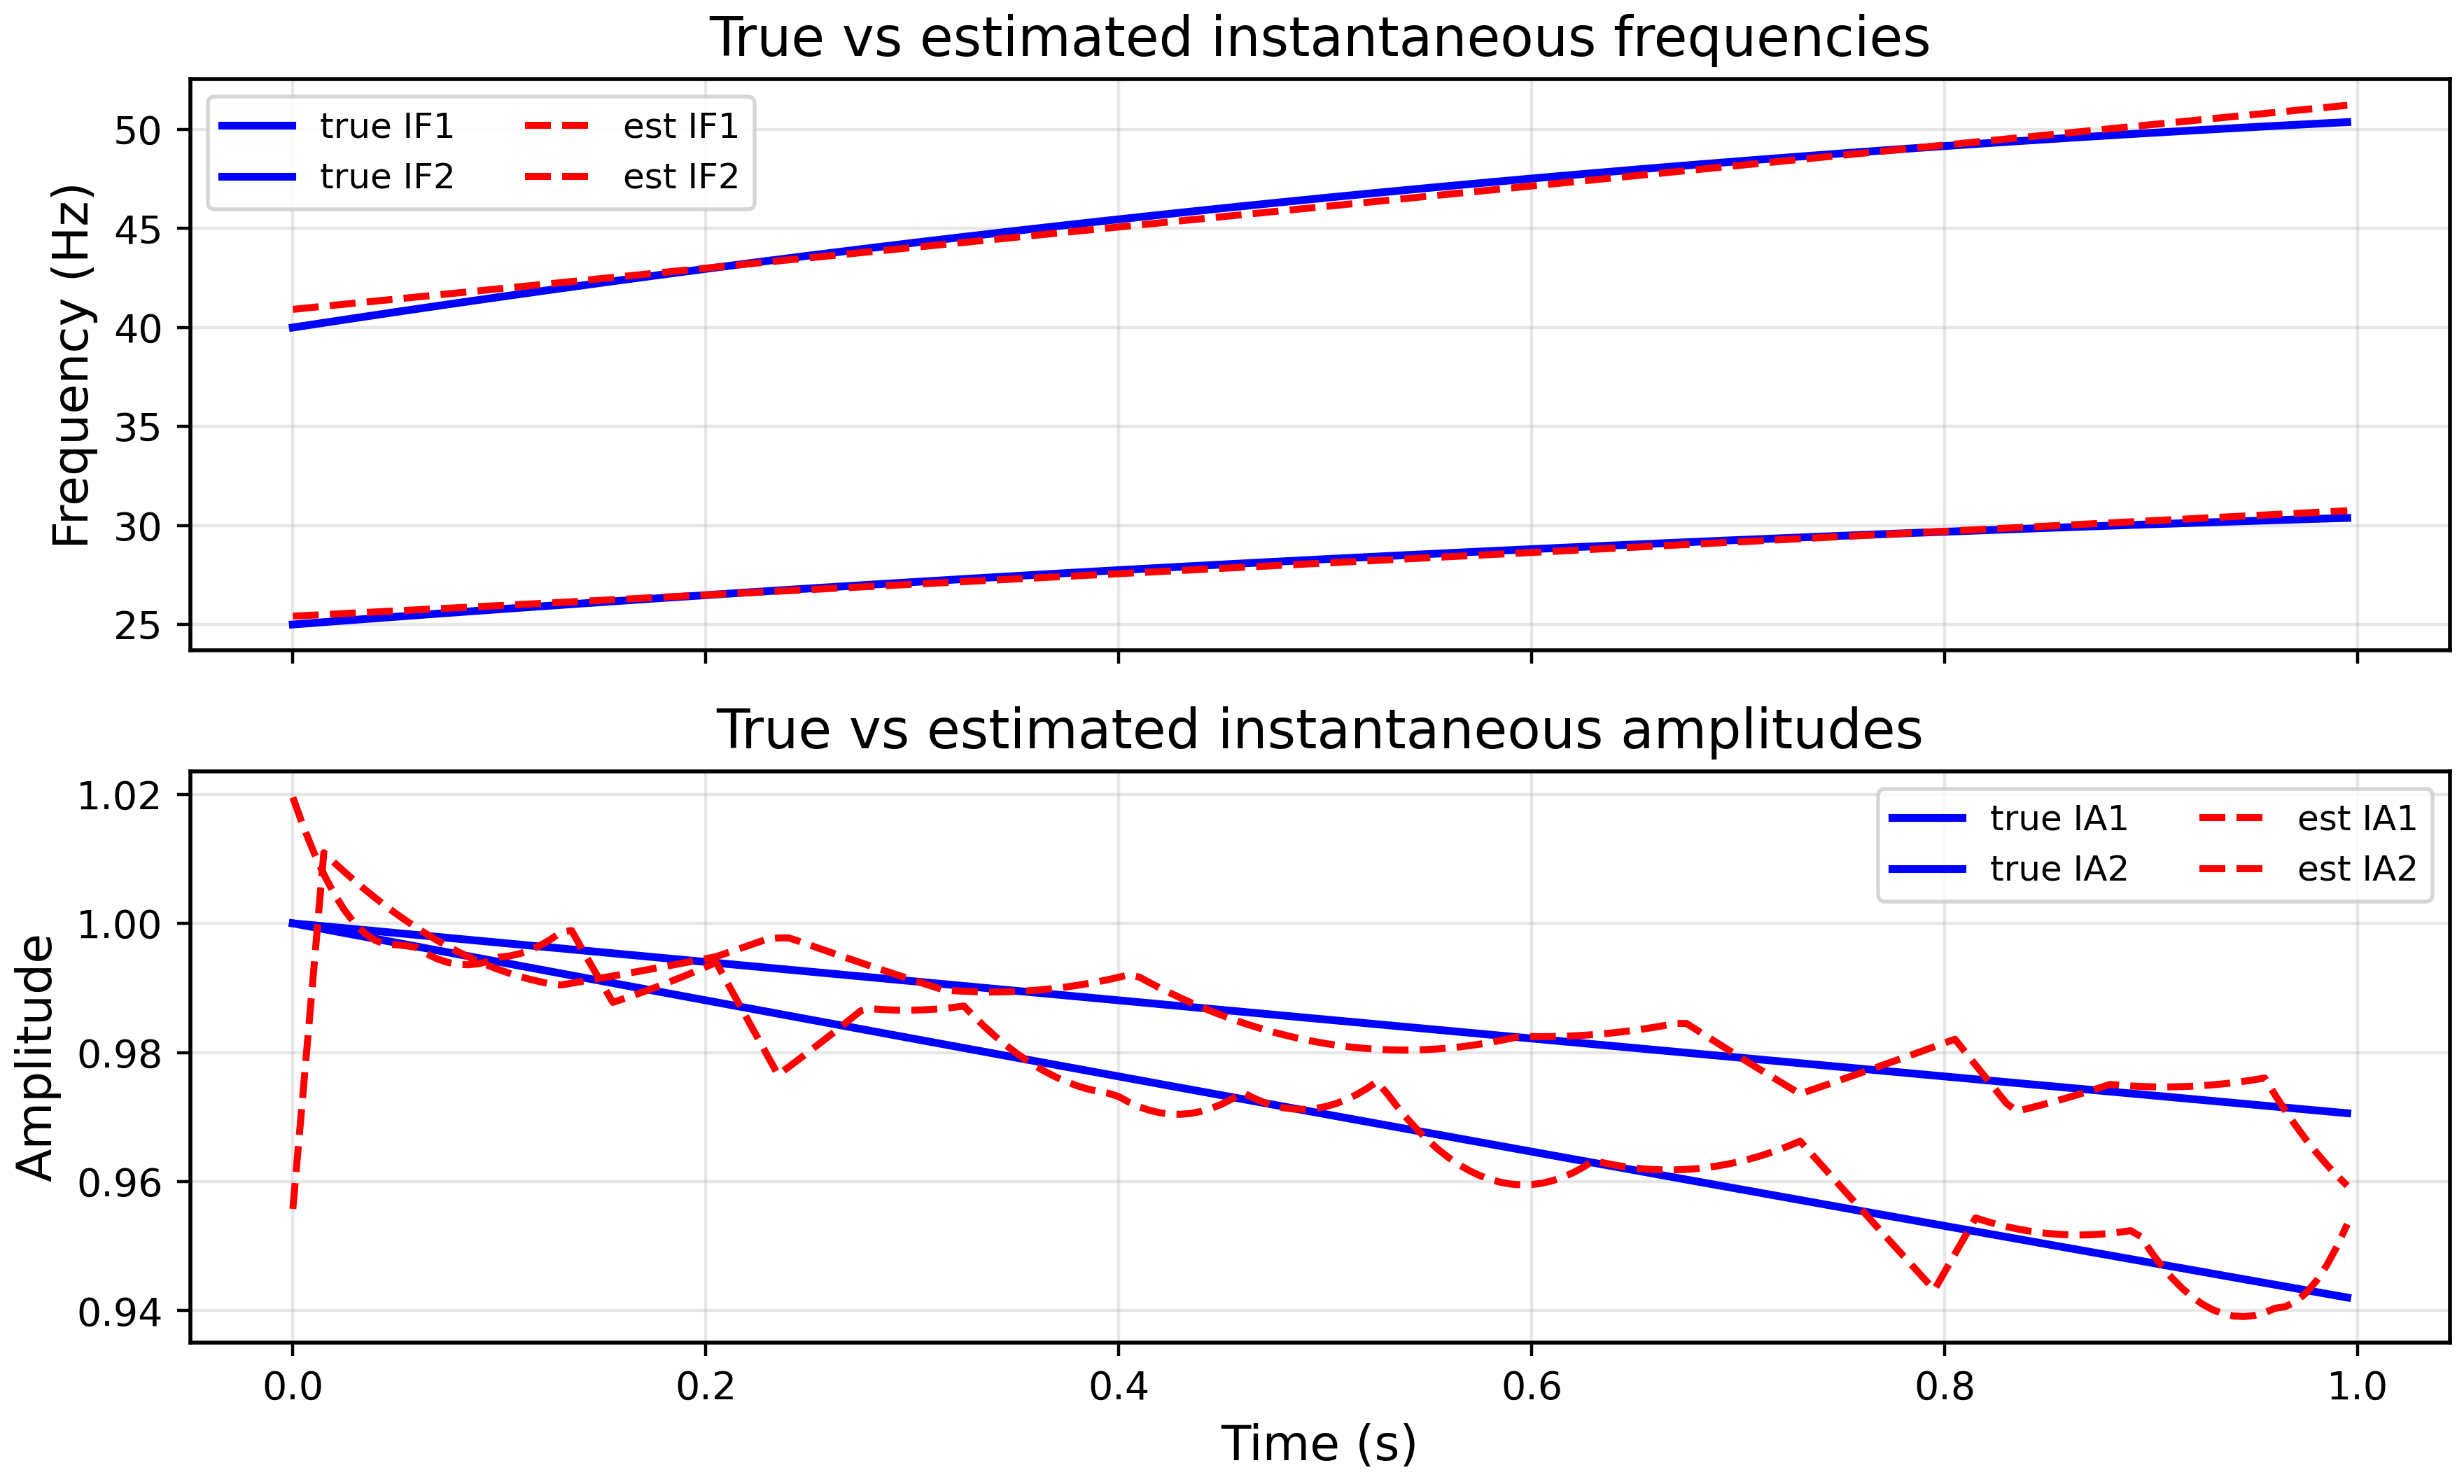

In [4]:
plot_IMFs(signal, estMode)
plt.suptitle("AVNCMD recovered modes", fontsize=12)
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
axes[0].plot(t, f_1t, "b-", lw=2, label="true IF1")
axes[0].plot(t, f_2t, "b-", lw=2, label="true IF2")
axes[0].plot(t, estIF[0], "r--", lw=1.8, label="est IF1")
axes[0].plot(t, estIF[1], "r--", lw=1.8, label="est IF2")
axes[0].set_ylabel("Frequency (Hz)")
axes[0].set_title("True vs estimated instantaneous frequencies")
axes[0].legend(loc="best", ncol=2, fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, a1, "b-", lw=2, label="true IA1")
axes[1].plot(t, a2, "b-", lw=2, label="true IA2")
axes[1].plot(t, estIA[0], "r--", lw=1.8, label="est IA1")
axes[1].plot(t, estIA[1], "r--", lw=1.8, label="est IA2")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("True vs estimated instantaneous amplitudes")
axes[1].legend(loc="best", ncol=2, fontsize=9)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Watching the adaptive process

After `fit_transform`, PySDKit stores the full IF / mode history on the instance:

- `avncmd.estIF` — shape `(K, N, n_iters)`
- `avncmd.estMode` — shape `(K, N, n_iters)`

Plotting IF trajectories across iterations makes the **data-driven carrier update** visible: constant seeds bend toward the true chirp laws as $\beta_{\mathrm{thin}}$ anneals and the Bayesian dictionary adapts.

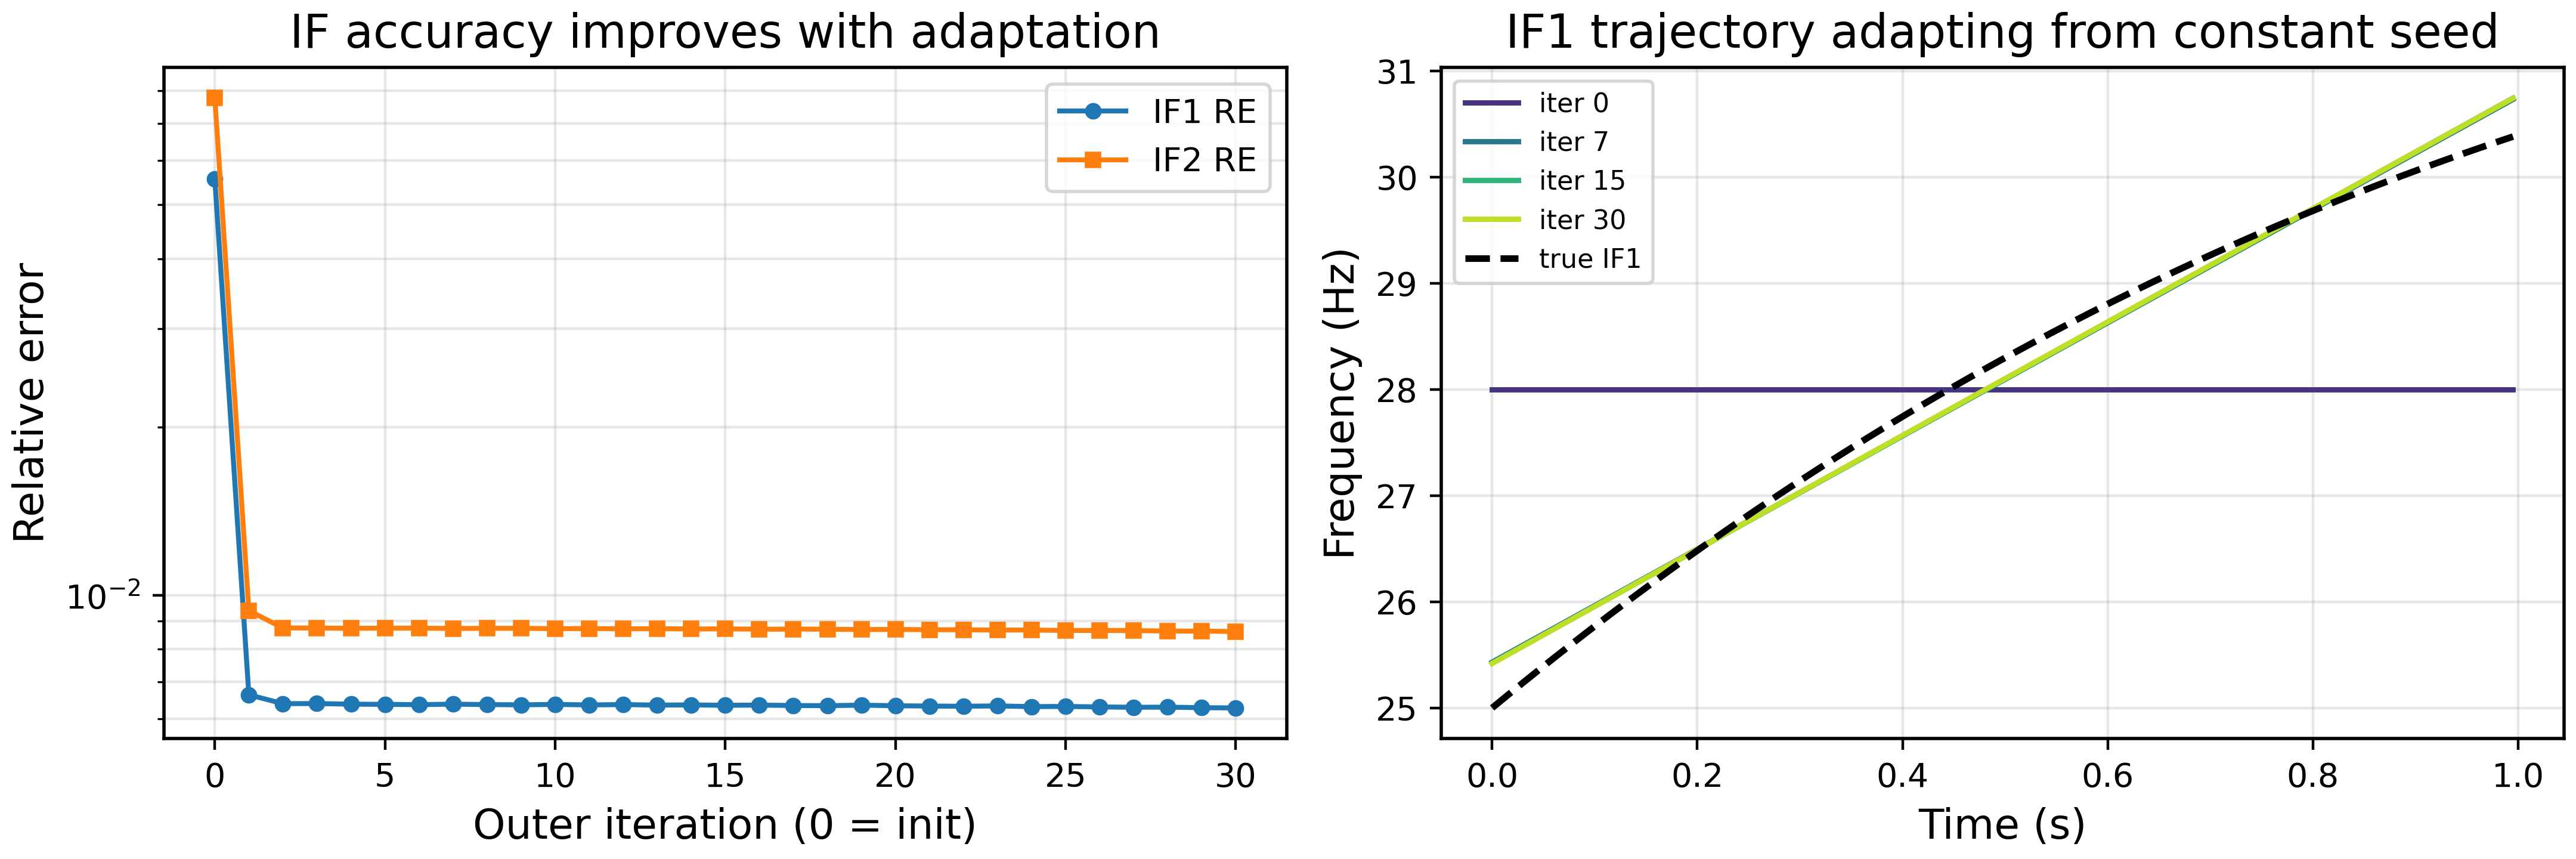

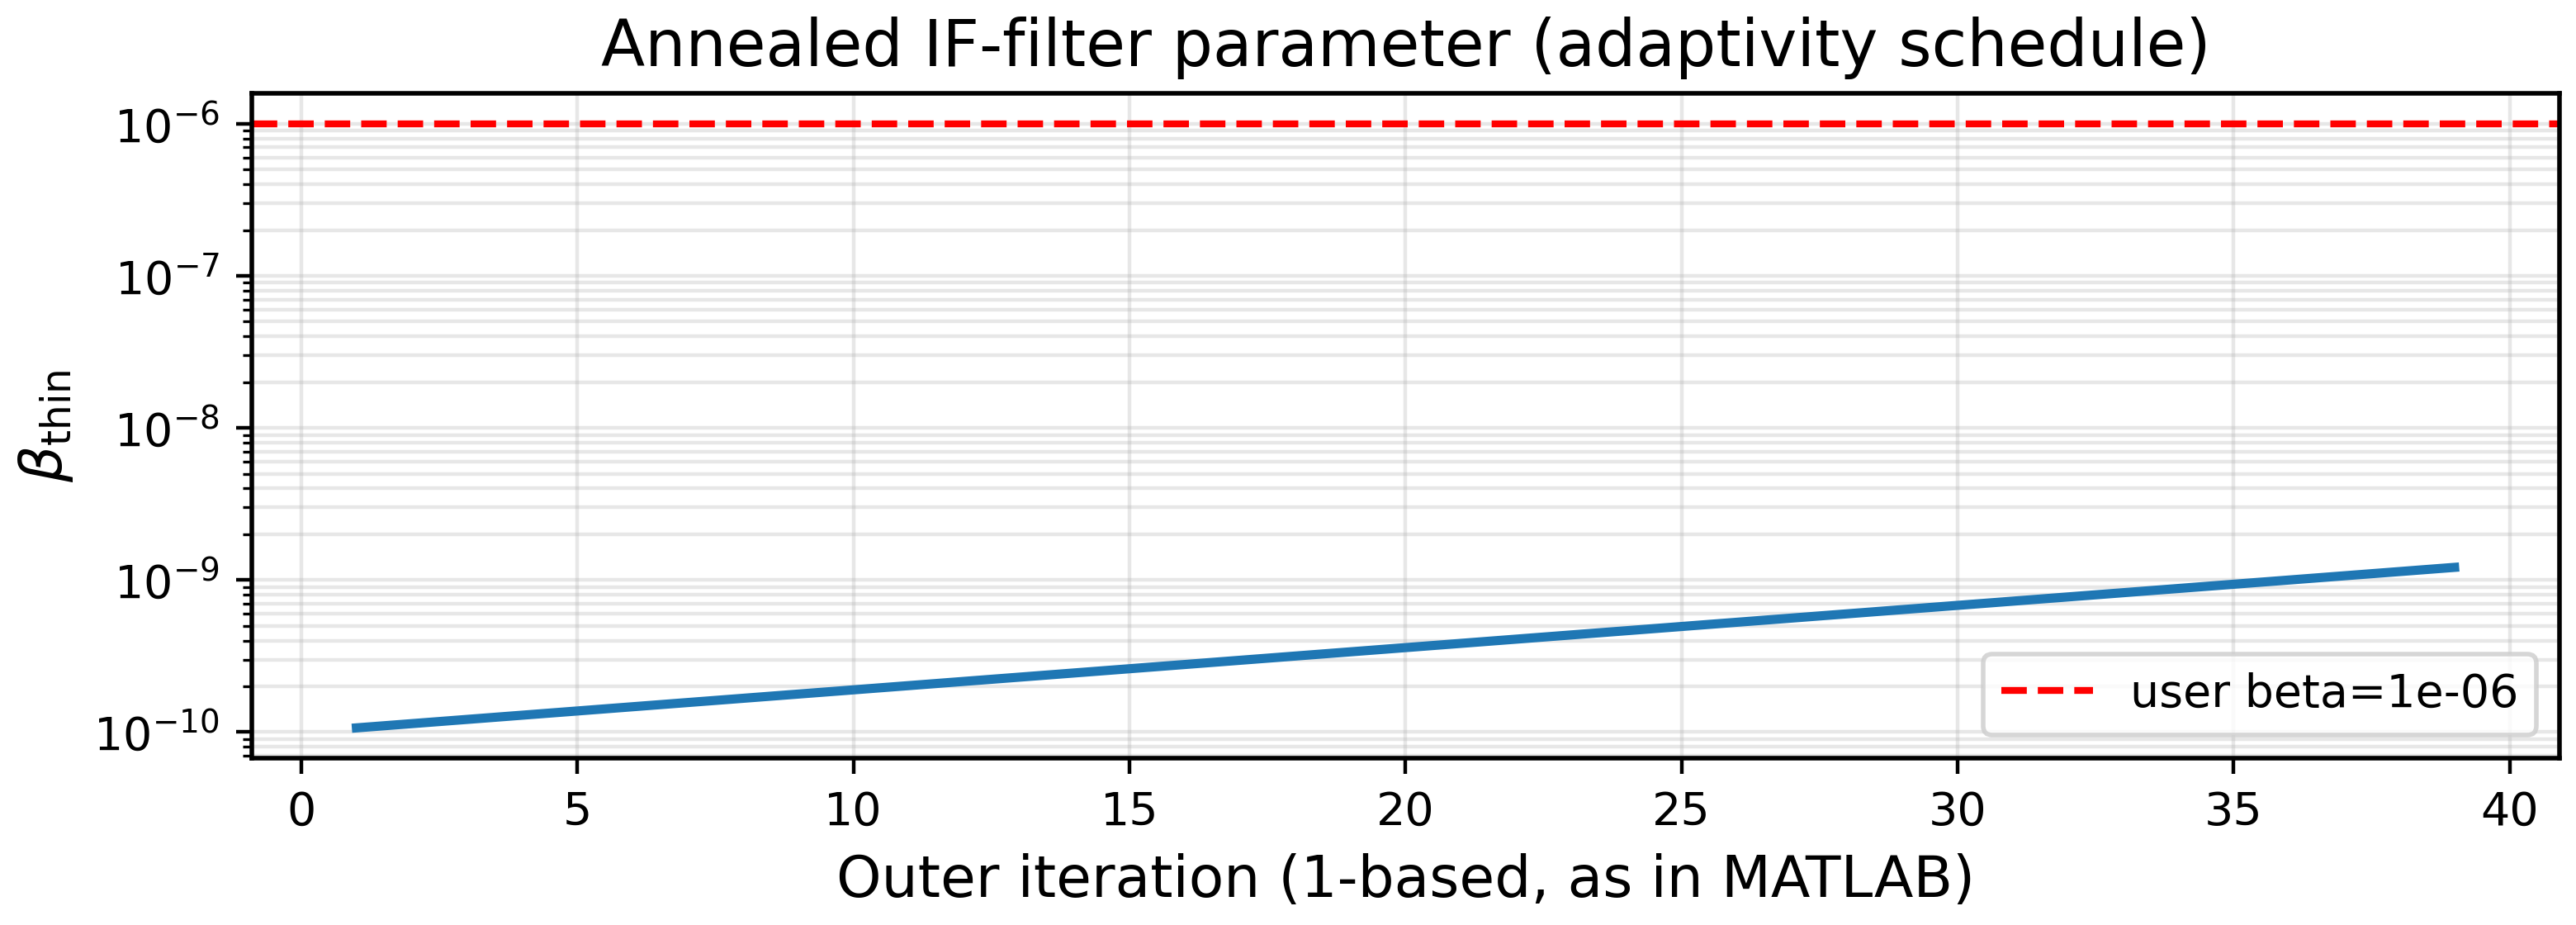

In [5]:
IF_hist = avncmd.estIF.copy()  # (K, N, T)
n_iters = IF_hist.shape[-1]

# Align history order with the final (possibly swapped) labeling
if swap:
    IF_hist = IF_hist[[1, 0], :, :]

# Relative IF error vs outer iteration (skip init at index 0 for "after update")
iters = np.arange(n_iters)
re1 = np.array([relative_error(IF_hist[0, :, j], f_1t) for j in iters])
re2 = np.array([relative_error(IF_hist[1, :, j], f_2t) for j in iters])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].semilogy(iters, re1, "o-", ms=4, label="IF1 RE")
axes[0].semilogy(iters, re2, "s-", ms=4, label="IF2 RE")
axes[0].set_xlabel("Outer iteration (0 = init)")
axes[0].set_ylabel("Relative error")
axes[0].set_title("IF accuracy improves with adaptation")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.3)

# Snapshot of IF curves at selected iterations
snap = sorted(set([0, max(1, n_iters // 4), max(2, n_iters // 2), n_iters - 1]))
cmap = plt.cm.viridis(np.linspace(0.15, 0.9, len(snap)))
for c, j in zip(cmap, snap):
    axes[1].plot(t, IF_hist[0, :, j], color=c, lw=1.6, label=f"iter {j}")
axes[1].plot(t, f_1t, "k--", lw=2, label="true IF1")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Frequency (Hz)")
axes[1].set_title("IF1 trajectory adapting from constant seed")
axes[1].legend(fontsize=8, loc="best")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Illustrate the beta annealing schedule used inside the loop
beta_user = 1e-6
iters_plot = np.arange(1, max(n_iters, 40))
beta_thin = np.minimum(10.0 ** (iters_plot / 36.0 - 10.0), beta_user)

fig, ax = plt.subplots(figsize=(8, 3))
ax.semilogy(iters_plot, beta_thin, lw=2)
ax.axhline(beta_user, color="r", ls="--", label=f"user beta={beta_user:g}")
ax.set_xlabel("Outer iteration (1-based, as in MATLAB)")
ax.set_ylabel(r"$\beta_{\mathrm{thin}}$")
ax.set_title("Annealed IF-filter parameter (adaptivity schedule)")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Takeaways

- **VNCMD** demodulates wide-band chirps into narrow-band $(u_k,v_k)$ but needs a carefully chosen bandwidth $\alpha$.
- **AVNCMD** keeps that geometry and adds three adaptive pieces:
  1. **Bayesian sparse estimation** of demodulated coefficients (learns effective regularization / active dictionary).
  2. **Arctangent IF increments** that correct carriers from current $(u_k,v_k)$, then rebuild $A$.
  3. **Annealed $\beta$** for stable low-pass correction of IF increments.
- Together, IAs and IFs are estimated jointly and iteratively, enabling a high-resolution time–frequency picture of NCSs.
- In PySDKit: `from pysdkit import AVNCMD`, then `estIF, estMode, estIA = AVNCMD(...).fit_transform(signal, iniIF=..., fs=...)`.

**Further reading**

- Chen et al., *Nonlinear Chirp Mode Decomposition*, IEEE TSP, 2017 (VNCMD).
- Liang et al., *Adaptive Variational Nonlinear Chirp Mode Decomposition*, ICASSP 2022 (this method).
- MATLAB reference: https://github.com/HauLiang/AVNCMD